# EconML Tutorial 06: Meta-Learners: S, T, And X Learners

This notebook introduces EconML's classic meta-learners for heterogeneous treatment effects:

- `SLearner`: one outcome model with treatment included as a feature;
- `TLearner`: separate outcome models for treated and untreated units;
- `XLearner`: two outcome models plus imputed treatment-effect models, designed to help when treatment groups are imbalanced.

The causal question is the same as before:

> How much would the outcome change for each unit if treatment were applied instead of not applied?

The modeling style is different. Meta-learners are outcome-model-based strategies. They are easier to explain than DML in some settings, but they rely heavily on the quality of outcome models and the overlap between treated and untreated units.

## Learning Goals

By the end of this notebook, you should be able to:

- explain the S-learner, T-learner, and X-learner in plain language;
- understand why EconML meta-learners use one `X` matrix rather than separate `X` and `W` arguments;
- fit `SLearner`, `TLearner`, and `XLearner` on a truth-known teaching dataset;
- compare outcome-model quality by treatment arm;
- evaluate CATE recovery, ranking, segment effects, and targeting performance;
- use model-agnostic permutation diagnostics to understand which features drive CATE predictions;
- decide when each meta-learner is a reasonable first choice.

## The Three Meta-Learner Ideas

Meta-learners turn supervised learning models into treatment-effect estimators.

`S-learner`:

- Fits one model: `Y ~ X + T`.
- Estimates CATE by predicting twice for each row: once with `T=1`, once with `T=0`, then subtracting.
- Strength: simple and uses all data in one model.
- Risk: the model may underuse the treatment feature, especially when treatment effects are subtle.

`T-learner`:

- Fits two models: one on treated rows and one on untreated rows.
- Estimates CATE as `predicted Y under treatment - predicted Y under control`.
- Strength: lets treated and untreated response surfaces differ freely.
- Risk: one arm can be poorly learned if treatment groups are imbalanced.

`X-learner`:

- Starts like a T-learner, then imputes treatment effects for each group.
- Fits CATE models to those imputed effects.
- Combines the two CATE models using propensity weights.
- Strength: often helpful when one treatment arm is smaller than the other.
- Risk: more moving pieces, more dependence on nuisance quality.

## Tutorial Flow

This lesson follows a comparison-first structure:

1. Create an imbalanced binary-treatment dataset with known CATE.
2. Check raw bias, covariate imbalance, and propensity overlap.
3. Explain why EconML meta-learners use a single feature matrix.
4. Fit S-, T-, and X-learners.
5. Compare with manual S- and T-learner calculations.
6. Evaluate CATE recovery, decile calibration, and segment summaries.
7. Inspect model-agnostic CATE feature sensitivity.
8. Compare treatment targeting rules.
9. Summarize when each learner is likely to work well or fail.

## Setup

This cell imports the packages used in the lesson, creates output folders, fixes a random seed, and checks that EconML is available. The warning filters keep output readable without hiding execution errors.

In [1]:
from pathlib import Path
import os
import warnings
import importlib.metadata as importlib_metadata

# Keep Matplotlib cache files in a writable location during notebook execution.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-ranking-sys")

warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*X does not have valid feature names.*")
warnings.filterwarnings("ignore", message=".*The final model has a nonzero intercept.*")
warnings.filterwarnings("ignore", message=".*Co-variance matrix is underdetermined.*")
warnings.filterwarnings("ignore", module="sklearn.linear_model._logistic")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, mean_squared_error, roc_auc_score
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

try:
    import econml
    from econml.metalearners import SLearner, TLearner, XLearner
    ECONML_AVAILABLE = True
    ECONML_VERSION = getattr(econml, "__version__", "unknown")
except Exception as exc:
    ECONML_AVAILABLE = False
    ECONML_VERSION = f"import failed: {type(exc).__name__}: {exc}"

RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)

OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print(f"EconML available: {ECONML_AVAILABLE}")
print(f"EconML version: {ECONML_VERSION}")
print(f"Figures will be saved to: {FIGURE_DIR.resolve()}")
print(f"Tables will be saved to: {TABLE_DIR.resolve()}")

EconML available: True
EconML version: 0.16.0
Figures will be saved to: /home/apex/Documents/ranking_sys/notebooks/tutorials/econml/outputs/figures
Tables will be saved to: /home/apex/Documents/ranking_sys/notebooks/tutorials/econml/outputs/tables


What this shows: the notebook is ready if EconML imports successfully. All saved artifacts use the `06_` prefix so they are easy to find in the shared tutorial output folder.

## Meta-Learner Map

The next table gives a compact comparison of S-, T-, and X-learners before we start fitting models.

In [2]:
meta_learner_map = pd.DataFrame(
    [
        {
            "learner": "S-learner",
            "models fitted": "One outcome model",
            "effect estimate": "Predict each row with T=1 and T=0, then subtract",
            "strength": "Simple and data-efficient",
            "main risk": "Treatment signal can be washed out if the outcome model ignores T",
        },
        {
            "learner": "T-learner",
            "models fitted": "Two outcome models, one per treatment arm",
            "effect estimate": "Predicted treated outcome minus predicted control outcome",
            "strength": "Allows very different response surfaces by arm",
            "main risk": "Small treatment arm can have a weak outcome model",
        },
        {
            "learner": "X-learner",
            "models fitted": "Two outcome models, two imputed-effect models, and a propensity model",
            "effect estimate": "Propensity-weighted combination of imputed-effect models",
            "strength": "Often useful with treatment imbalance",
            "main risk": "More nuisance-model dependence and more tuning choices",
        },
    ]
)

meta_learner_map.to_csv(TABLE_DIR / "06_meta_learner_map.csv", index=False)
display(meta_learner_map)

,learner,models fitted,effect estimate,strength,main risk
0,S-learner,One outcome model,"Predict each row with T=1 and T=0, then subtract",Simple and data-efficient,Treatment signal can be washed out if the outc...
1,T-learner,"Two outcome models, one per treatment arm",Predicted treated outcome minus predicted cont...,Allows very different response surfaces by arm,Small treatment arm can have a weak outcome model
2,X-learner,"Two outcome models, two imputed-effect models,...",Propensity-weighted combination of imputed-eff...,Often useful with treatment imbalance,More nuisance-model dependence and more tuning...


What this shows: all three learners estimate CATE through supervised prediction, but they organize the prediction problem differently. The best choice depends on treatment balance, response-surface complexity, and reporting needs.

## Synthetic Teaching Data

The dataset below intentionally has an imbalanced treatment rate. That makes the X-learner worth discussing, because X-learners were designed partly for settings where one treatment arm has fewer observations.

The true CATE is nonlinear and depends on several pre-treatment features. The outcome is continuous, treatment is binary, and assignment is confounded by observed covariates.

In [3]:
n = 3_200

baseline_need = rng.normal(0, 1, size=n)
prior_engagement = rng.normal(0, 1, size=n)
friction_score = 0.55 * baseline_need - 0.25 * prior_engagement + rng.normal(0, 0.85, size=n)
content_affinity = 0.40 * prior_engagement + rng.normal(0, 0.95, size=n)
price_sensitivity = rng.normal(0, 1, size=n)
trust_score = rng.normal(0, 1, size=n)
recency_gap = rng.normal(0, 1, size=n)
region_risk = rng.binomial(1, 0.34, size=n)
high_need_segment = (baseline_need > 0.55).astype(int)

account_tenure = rng.normal(0, 1, size=n)
seasonality_index = rng.normal(0, 1, size=n)
device_stability = rng.normal(0, 1, size=n)
traffic_intensity = rng.normal(0, 1, size=n)

# The intercept is negative so treatment is less common than control.
propensity_logit = (
    -1.05
    + 0.85 * baseline_need
    + 0.45 * prior_engagement
    + 0.40 * friction_score
    + 0.30 * content_affinity
    - 0.22 * trust_score
    + 0.28 * region_risk
    + 0.22 * high_need_segment
    - 0.25 * account_tenure
    + 0.20 * seasonality_index
    + 0.16 * traffic_intensity
)
propensity = 1 / (1 + np.exp(-propensity_logit))
propensity = np.clip(propensity, 0.025, 0.95)
treatment = rng.binomial(1, propensity, size=n)

true_cate = (
    0.34
    + 0.36 * high_need_segment
    + 0.22 * np.tanh(prior_engagement)
    - 0.22 * np.maximum(friction_score, 0)
    + 0.18 * content_affinity
    - 0.16 * region_risk
    - 0.12 * (price_sensitivity > 0.75).astype(float)
    + 0.10 * np.sin(content_affinity + baseline_need)
)

mu0 = (
    2.15
    + 0.78 * baseline_need
    + 0.58 * prior_engagement
    - 0.48 * friction_score
    + 0.28 * content_affinity
    + 0.22 * trust_score
    + 0.34 * account_tenure
    + 0.22 * seasonality_index
    + 0.18 * device_stability
    + 0.18 * traffic_intensity
    + 0.15 * region_risk
    + 0.12 * baseline_need * friction_score
)
mu1 = mu0 + true_cate
noise = rng.normal(0, 0.90, size=n)
outcome = np.where(treatment == 1, mu1, mu0) + noise

teaching_df = pd.DataFrame(
    {
        "user_id": np.arange(n),
        "baseline_need": baseline_need,
        "prior_engagement": prior_engagement,
        "friction_score": friction_score,
        "content_affinity": content_affinity,
        "price_sensitivity": price_sensitivity,
        "trust_score": trust_score,
        "recency_gap": recency_gap,
        "region_risk": region_risk,
        "high_need_segment": high_need_segment,
        "account_tenure": account_tenure,
        "seasonality_index": seasonality_index,
        "device_stability": device_stability,
        "traffic_intensity": traffic_intensity,
        "propensity": propensity,
        "treatment": treatment,
        "outcome": outcome,
        "mu0": mu0,
        "mu1": mu1,
        "true_cate": true_cate,
    }
)

teaching_df.head()

,user_id,baseline_need,prior_engagement,friction_score,content_affinity,price_sensitivity,trust_score,recency_gap,region_risk,high_need_segment,account_tenure,seasonality_index,device_stability,traffic_intensity,propensity,treatment,outcome,mu0,mu1,true_cate
0,0,-0.7931,-1.2901,-0.3725,-0.1556,-1.1530,-1.3164,-0.7477,1,0,-3.0473,-0.3020,-0.9402,2.2139,0.2942,0,-0.8563,-0.0591,-0.1774,-0.1183
1,1,0.2406,0.2599,-0.4635,0.3219,-0.9692,1.3240,-0.4711,0,0,-0.5008,-0.4229,1.2210,0.6131,0.2749,1,4.0980,3.1457,3.6529,0.5072
2,2,-1.8963,-0.3197,-0.9924,-0.2171,-1.2255,-0.4610,0.0474,0,0,-0.0048,-0.8700,-1.7494,-0.0209,0.0341,0,2.8359,0.5137,0.6609,0.1472
3,3,1.3958,-0.2729,0.3750,0.4374,0.6809,-1.5277,1.4382,0,1,1.0852,-0.2230,-2.3089,0.9227,0.6643,1,4.5997,2.8200,3.5543,0.7342
4,4,0.6383,-1.4263,0.6936,-2.0093,0.5773,1.1598,2.8067,0,1,-1.8344,-0.9164,-0.2073,-0.3209,0.2166,0,0.1130,0.3130,0.2047,-0.1083


What this shows: treatment is observational and imbalanced, not randomized. The oracle columns make it possible to grade the meta-learners, but those fields will not be used as model inputs.

## Field Dictionary

Meta-learners in EconML use one `X` matrix. That `X` should include all pre-treatment covariates needed to model potential outcomes and treatment-effect heterogeneity.

This differs from the DML notebooks where we separated `X` and `W`. Here we still track conceptual roles, but the fitted meta-learners receive one combined pre-treatment feature table.

In [4]:
effect_modifier_cols = [
    "baseline_need",
    "prior_engagement",
    "friction_score",
    "content_affinity",
    "price_sensitivity",
    "region_risk",
    "high_need_segment",
]
extra_adjustment_cols = ["trust_score", "recency_gap", "account_tenure", "seasonality_index", "device_stability", "traffic_intensity"]
all_feature_cols = effect_modifier_cols + extra_adjustment_cols
true_driver_cols = [
    "baseline_need",
    "prior_engagement",
    "friction_score",
    "content_affinity",
    "price_sensitivity",
    "region_risk",
    "high_need_segment",
]

field_rows = []
for col in effect_modifier_cols:
    field_rows.append(
        {
            "column": col,
            "conceptual_role": "effect modifier and pre-treatment covariate",
            "included_in_econml_X": "yes",
            "observed_in_real_analysis": "yes",
            "description": "Feature expected to help explain treatment-effect heterogeneity.",
            "true_cate_driver": "yes" if col in true_driver_cols else "no",
        }
    )
for col in extra_adjustment_cols:
    field_rows.append(
        {
            "column": col,
            "conceptual_role": "pre-treatment outcome or assignment predictor",
            "included_in_econml_X": "yes",
            "observed_in_real_analysis": "yes",
            "description": "Feature included because meta-learners use one X table for outcome modeling and heterogeneity.",
            "true_cate_driver": "no",
        }
    )
for col, role, description in [
    ("treatment", "treatment", "Binary intervention indicator."),
    ("outcome", "outcome", "Observed post-treatment outcome."),
    ("propensity", "oracle", "True treatment probability from the simulated assignment process."),
    ("mu0", "oracle", "True conditional mean outcome under control."),
    ("mu1", "oracle", "True conditional mean outcome under treatment."),
    ("true_cate", "oracle", "Known individual treatment effect used only for tutorial evaluation."),
]:
    field_rows.append(
        {
            "column": col,
            "conceptual_role": role,
            "included_in_econml_X": "no",
            "observed_in_real_analysis": "yes" if role in ["treatment", "outcome"] else "no",
            "description": description,
            "true_cate_driver": "not applicable",
        }
    )

field_dictionary = pd.DataFrame(field_rows)
field_dictionary.to_csv(TABLE_DIR / "06_field_dictionary.csv", index=False)
display(field_dictionary)

,column,conceptual_role,included_in_econml_X,observed_in_real_analysis,description,true_cate_driver
0,baseline_need,effect modifier and pre-treatment covariate,yes,yes,Feature expected to help explain treatment-eff...,yes
1,prior_engagement,effect modifier and pre-treatment covariate,yes,yes,Feature expected to help explain treatment-eff...,yes
2,friction_score,effect modifier and pre-treatment covariate,yes,yes,Feature expected to help explain treatment-eff...,yes
3,content_affinity,effect modifier and pre-treatment covariate,yes,yes,Feature expected to help explain treatment-eff...,yes
4,price_sensitivity,effect modifier and pre-treatment covariate,yes,yes,Feature expected to help explain treatment-eff...,yes
5,region_risk,effect modifier and pre-treatment covariate,yes,yes,Feature expected to help explain treatment-eff...,yes
6,high_need_segment,effect modifier and pre-treatment covariate,yes,yes,Feature expected to help explain treatment-eff...,yes
7,trust_score,pre-treatment outcome or assignment predictor,yes,yes,Feature included because meta-learners use one...,no
8,recency_gap,pre-treatment outcome or assignment predictor,yes,yes,Feature included because meta-learners use one...,no
9,account_tenure,pre-treatment outcome or assignment predictor,yes,yes,Feature included because meta-learners use one...,no


What this shows: because the meta-learner API uses one `X`, feature selection has to be done carefully. We include all valid pre-treatment predictors, but we still remember which features are true effect drivers in the simulation.

## Basic Shape And Treatment Imbalance

This summary checks the sample size, number of features, treatment rate, and true effect scale. The treatment rate is intentionally below 50 percent to create a useful X-learner teaching case.

In [5]:
basic_summary = pd.DataFrame(
    [
        {"metric": "rows", "value": len(teaching_df)},
        {"metric": "columns", "value": teaching_df.shape[1]},
        {"metric": "econml_X_features", "value": len(all_feature_cols)},
        {"metric": "treatment_rate", "value": teaching_df["treatment"].mean()},
        {"metric": "control_rate", "value": 1 - teaching_df["treatment"].mean()},
        {"metric": "outcome_mean", "value": teaching_df["outcome"].mean()},
        {"metric": "true_ate", "value": teaching_df["true_cate"].mean()},
        {"metric": "true_cate_std", "value": teaching_df["true_cate"].std()},
        {"metric": "true_cate_min", "value": teaching_df["true_cate"].min()},
        {"metric": "true_cate_max", "value": teaching_df["true_cate"].max()},
    ]
)

basic_summary.to_csv(TABLE_DIR / "06_basic_summary.csv", index=False)
display(basic_summary)

,metric,value
0,rows,"3,200.0000"
1,columns,20.0000
2,econml_X_features,13.0000
3,treatment_rate,0.3378
4,control_rate,0.6622
5,outcome_mean,2.4052
6,true_ate,0.2821
7,true_cate_std,0.3878
8,true_cate_min,-0.8383
9,true_cate_max,1.3454


What this shows: the smaller treated group means the treated outcome surface is harder to learn than the control outcome surface. That imbalance is exactly why the T-learner and X-learner may behave differently.

## True CATE Distribution

The true CATE distribution shows the heterogeneity that the learners are trying to recover. This is available only because the data is simulated.

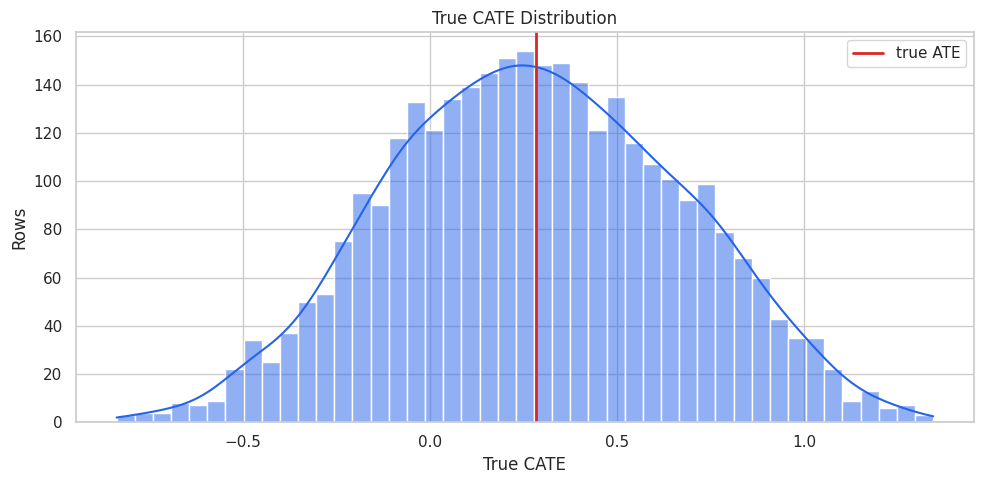

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(teaching_df["true_cate"], bins=45, kde=True, color="#2563eb", ax=ax)
ax.axvline(teaching_df["true_cate"].mean(), color="#dc2626", linewidth=2, label="true ATE")
ax.set_title("True CATE Distribution")
ax.set_xlabel("True CATE")
ax.set_ylabel("Rows")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "06_true_cate_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: the true treatment effect varies meaningfully across units. A meta-learner should be judged on how well it recovers this variation, not only on the overall average.

## Raw Treated-Versus-Control Difference

A raw outcome difference ignores both confounding and treatment imbalance. It is useful as a baseline warning, not as a credible causal estimate.

In [7]:
raw_group_summary = (
    teaching_df.groupby("treatment")
    .agg(
        rows=("outcome", "size"),
        observed_outcome_mean=("outcome", "mean"),
        true_cate_mean=("true_cate", "mean"),
        propensity_mean=("propensity", "mean"),
        baseline_need_mean=("baseline_need", "mean"),
        friction_score_mean=("friction_score", "mean"),
        content_affinity_mean=("content_affinity", "mean"),
    )
    .reset_index()
)
raw_difference = (
    raw_group_summary.loc[raw_group_summary["treatment"].eq(1), "observed_outcome_mean"].iloc[0]
    - raw_group_summary.loc[raw_group_summary["treatment"].eq(0), "observed_outcome_mean"].iloc[0]
)
true_ate = teaching_df["true_cate"].mean()

raw_difference_summary = pd.DataFrame(
    [
        {"quantity": "raw treated minus untreated outcome mean", "value": raw_difference},
        {"quantity": "true ATE", "value": true_ate},
        {"quantity": "raw difference minus true ATE", "value": raw_difference - true_ate},
    ]
)

raw_group_summary.to_csv(TABLE_DIR / "06_raw_group_summary.csv", index=False)
raw_difference_summary.to_csv(TABLE_DIR / "06_raw_difference_vs_truth.csv", index=False)
display(raw_group_summary)
display(raw_difference_summary)

,treatment,rows,observed_outcome_mean,true_cate_mean,propensity_mean,baseline_need_mean,friction_score_mean,content_affinity_mean
0,0,2119,2.0575,0.2194,0.2440,-0.3450,-0.2528,-0.1007
1,1,1081,3.0868,0.4051,0.5149,0.5807,0.3938,0.2232


,quantity,value
0,raw treated minus untreated outcome mean,1.0292
1,true ATE,0.2821
2,raw difference minus true ATE,0.7471


What this shows: treated rows differ from control rows before treatment. Meta-learners can adjust only through the observed features included in `X`, so the feature table has to be causally defensible.

## Covariate Balance Table

Standardized mean differences show how different treated and untreated groups are before modeling. Large absolute values indicate observed confounding.

In [8]:
balance_rows = []
for col in all_feature_cols:
    treated_values = teaching_df.loc[teaching_df["treatment"].eq(1), col]
    control_values = teaching_df.loc[teaching_df["treatment"].eq(0), col]
    pooled_sd = np.sqrt((treated_values.var(ddof=1) + control_values.var(ddof=1)) / 2)
    balance_rows.append(
        {
            "covariate": col,
            "treated_mean": treated_values.mean(),
            "control_mean": control_values.mean(),
            "standardized_difference": (treated_values.mean() - control_values.mean()) / pooled_sd,
        }
    )

balance_table = pd.DataFrame(balance_rows).sort_values("standardized_difference", key=lambda s: s.abs(), ascending=False)
balance_table.to_csv(TABLE_DIR / "06_covariate_balance.csv", index=False)
display(balance_table)

,covariate,treated_mean,control_mean,standardized_difference
0,baseline_need,0.5807,-0.3450,1.0164
6,high_need_segment,0.5245,0.1666,0.8121
2,friction_score,0.3938,-0.2528,0.6457
3,content_affinity,0.2232,-0.1007,0.3131
1,prior_engagement,0.2183,-0.0652,0.2819
9,account_tenure,-0.1518,0.0728,-0.2235
7,trust_score,-0.1004,0.0836,-0.1846
10,seasonality_index,0.0664,-0.0632,0.1315
5,region_risk,0.3608,0.3011,0.1271
12,traffic_intensity,0.0742,-0.0461,0.1216


What this shows: the treatment group is not directly comparable to the control group. Outcome-model meta-learners must use these pre-treatment features to model potential outcomes credibly.

## Covariate Balance Plot

The plot highlights the most imbalanced features, which are the visible sources of confounding in the teaching data.

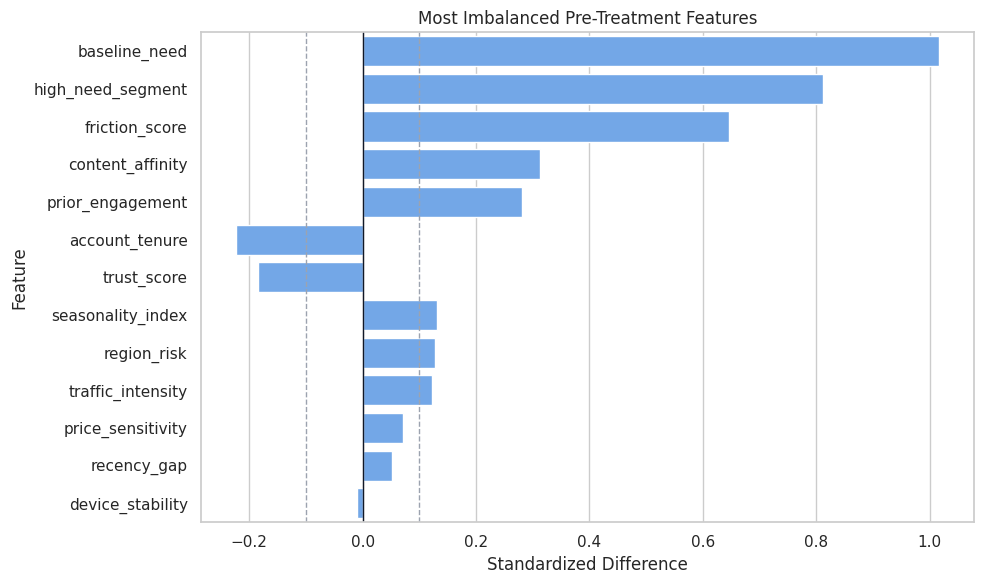

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=balance_table.head(13),
    x="standardized_difference",
    y="covariate",
    color="#60a5fa",
    ax=ax,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.axvline(0.10, color="#9ca3af", linewidth=1, linestyle="--")
ax.axvline(-0.10, color="#9ca3af", linewidth=1, linestyle="--")
ax.set_title("Most Imbalanced Pre-Treatment Features")
ax.set_xlabel("Standardized Difference")
ax.set_ylabel("Feature")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "06_covariate_balance.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: several features tied to treatment assignment are also tied to outcome and effect heterogeneity. This is why raw comparisons are misleading.

## Propensity Overlap

Meta-learners do not always use propensities directly, but overlap still matters. If treated and untreated rows occupy different feature regions, outcome models must extrapolate potential outcomes.

In [10]:
propensity_summary = (
    teaching_df.assign(propensity_bucket=pd.cut(teaching_df["propensity"], bins=np.linspace(0, 1, 11), include_lowest=True))
    .groupby("propensity_bucket", observed=True)
    .agg(
        rows=("propensity", "size"),
        treatment_rate=("treatment", "mean"),
        true_cate_mean=("true_cate", "mean"),
        baseline_need_mean=("baseline_need", "mean"),
    )
    .reset_index()
)
propensity_summary["propensity_bucket"] = propensity_summary["propensity_bucket"].astype(str)
propensity_summary.to_csv(TABLE_DIR / "06_propensity_bucket_summary.csv", index=False)
display(propensity_summary)

,propensity_bucket,rows,treatment_rate,true_cate_mean,baseline_need_mean
0,"(-0.001, 0.1]",600,0.0717,0.0352,-1.2195
1,"(0.1, 0.2]",609,0.1215,0.1622,-0.5350
2,"(0.2, 0.3]",481,0.2578,0.2083,-0.1530
3,"(0.3, 0.4]",402,0.3507,0.3051,0.1617
4,"(0.4, 0.5]",299,0.3980,0.4196,0.4313
5,"(0.5, 0.6]",248,0.5645,0.4497,0.6361
6,"(0.6, 0.7]",213,0.7089,0.5291,0.9077
7,"(0.7, 0.8]",168,0.7679,0.5889,1.1852
8,"(0.8, 0.9]",140,0.8786,0.6238,1.4535
9,"(0.9, 1.0]",40,0.9250,0.6005,2.0009


What this shows: treatment is less common overall, but there are still treated and untreated observations across useful propensity regions. That makes this suitable for meta-learner comparison.

## Propensity Overlap Plot

The histogram shows true propensity by observed treatment group. In real data, this would use an estimated propensity model.

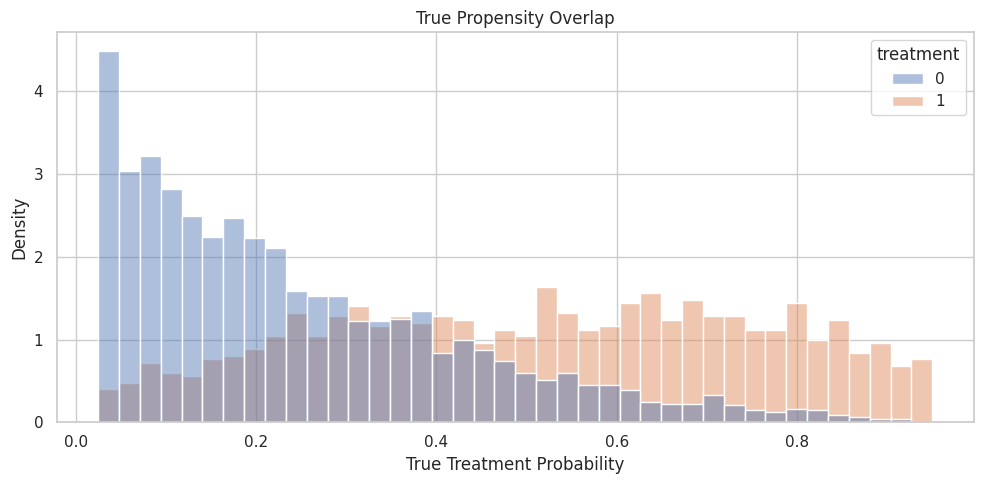

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=teaching_df,
    x="propensity",
    hue="treatment",
    bins=40,
    stat="density",
    common_norm=False,
    alpha=0.45,
    ax=ax,
)
ax.set_title("True Propensity Overlap")
ax.set_xlabel("True Treatment Probability")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "06_propensity_overlap.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: the treated distribution is shifted toward higher propensity, but it is not completely separated from controls. The overlap is usable, though not perfect.

## Train And Test Split

The train set is used to fit the learners. The test set is held out for truth-known evaluation of CATE recovery and targeting behavior.

In [12]:
train_idx, test_idx = train_test_split(
    teaching_df.index,
    test_size=0.35,
    random_state=RANDOM_SEED,
    stratify=teaching_df["treatment"],
)

train_df = teaching_df.loc[train_idx].reset_index(drop=True)
test_df = teaching_df.loc[test_idx].reset_index(drop=True)

split_summary = pd.DataFrame(
    [
        {"split": "train", "rows": len(train_df), "treatment_rate": train_df["treatment"].mean(), "true_ate": train_df["true_cate"].mean()},
        {"split": "test", "rows": len(test_df), "treatment_rate": test_df["treatment"].mean(), "true_ate": test_df["true_cate"].mean()},
    ]
)

split_summary.to_csv(TABLE_DIR / "06_train_test_split_summary.csv", index=False)
display(split_summary)

,split,rows,treatment_rate,true_ate
0,train,2080,0.3380,0.2716
1,test,1120,0.3375,0.3015


What this shows: stratification preserves the treatment imbalance in both splits. This lets the learner comparison focus on modeling strategy rather than a strange train/test split.

## Modeling Matrices

EconML's meta-learners take a single `X`. Here that matrix contains all valid pre-treatment features, including both effect modifiers and adjustment predictors.

In [13]:
Y_train = train_df["outcome"].to_numpy()
T_train = train_df["treatment"].to_numpy()
Y_test = test_df["outcome"].to_numpy()
T_test = test_df["treatment"].to_numpy()

X_train = train_df[all_feature_cols]
X_test = test_df[all_feature_cols]
true_cate_train = train_df["true_cate"].to_numpy()
true_cate_test = test_df["true_cate"].to_numpy()

matrix_summary = pd.DataFrame(
    [
        {"object": "Y_train", "rows": Y_train.shape[0], "columns": 1, "meaning": "Observed outcome."},
        {"object": "T_train", "rows": T_train.shape[0], "columns": 1, "meaning": "Observed binary treatment."},
        {"object": "X_train", "rows": X_train.shape[0], "columns": X_train.shape[1], "meaning": "All observed pre-treatment features for meta-learners."},
        {"object": "true_cate_test", "rows": true_cate_test.shape[0], "columns": 1, "meaning": "Oracle effect used only for evaluation."},
    ]
)

matrix_summary.to_csv(TABLE_DIR / "06_model_matrix_summary.csv", index=False)
display(matrix_summary)

,object,rows,columns,meaning
0,Y_train,2080,1,Observed outcome.
1,T_train,2080,1,Observed binary treatment.
2,X_train,2080,13,All observed pre-treatment features for meta-l...
3,true_cate_test,1120,1,Oracle effect used only for evaluation.


What this shows: unlike DML estimators, these meta-learners do not receive a separate control matrix. If a pre-treatment feature is needed for adjustment or outcome prediction, it must be included in `X`.

## Outcome Model Diagnostics By Arm

The T- and X-learners rely heavily on separate outcome models for treated and untreated rows. Because treatment is imbalanced, we should check how much data each arm has and how well arm-specific outcome models predict out of fold.

In [14]:
outcome_cv_rows = []
for arm_value, arm_name in [(0, "control"), (1, "treated")]:
    arm_mask = train_df["treatment"].eq(arm_value).to_numpy()
    arm_X = X_train.loc[arm_mask]
    arm_y = Y_train[arm_mask]
    arm_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    arm_model = RandomForestRegressor(n_estimators=140, min_samples_leaf=18, random_state=RANDOM_SEED, n_jobs=-1)
    arm_pred = cross_val_predict(arm_model, arm_X, arm_y, cv=arm_cv, method="predict")
    outcome_cv_rows.append(
        {
            "arm": arm_name,
            "rows": len(arm_y),
            "out_of_fold_rmse": np.sqrt(mean_squared_error(arm_y, arm_pred)),
            "outcome_mean": arm_y.mean(),
            "outcome_std": arm_y.std(),
        }
    )

arm_outcome_diagnostics = pd.DataFrame(outcome_cv_rows)
arm_outcome_diagnostics.to_csv(TABLE_DIR / "06_arm_outcome_diagnostics.csv", index=False)
display(arm_outcome_diagnostics)

,arm,rows,out_of_fold_rmse,outcome_mean,outcome_std
0,control,1377,1.0431,2.0125,1.4787
1,treated,703,1.1744,3.0281,1.7138


What this shows: the treated arm has fewer rows, so its outcome surface is harder to estimate. This is the T-learner's main vulnerability and the X-learner's motivation.

## Propensity Model Diagnostic

The X-learner uses a propensity model to combine imputed-effect models. This diagnostic checks whether treatment assignment is predictable from `X`.

In [15]:
propensity_probe = RandomForestClassifier(n_estimators=140, min_samples_leaf=20, random_state=RANDOM_SEED, n_jobs=-1)
propensity_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
propensity_oof = cross_val_predict(propensity_probe, X_train, T_train, cv=propensity_cv, method="predict_proba")[:, 1]
propensity_oof = np.clip(propensity_oof, 0.025, 0.975)

propensity_diagnostics = pd.DataFrame(
    [
        {"metric": "out_of_fold_auc", "value": roc_auc_score(T_train, propensity_oof)},
        {"metric": "out_of_fold_brier_score", "value": brier_score_loss(T_train, propensity_oof)},
        {"metric": "out_of_fold_log_loss", "value": log_loss(T_train, propensity_oof)},
        {"metric": "mean_predicted_propensity", "value": propensity_oof.mean()},
        {"metric": "observed_treatment_rate", "value": T_train.mean()},
    ]
)

propensity_diagnostics.to_csv(TABLE_DIR / "06_propensity_model_diagnostics.csv", index=False)
display(propensity_diagnostics)

,metric,value
0,out_of_fold_auc,0.7960
1,out_of_fold_brier_score,0.1684
2,out_of_fold_log_loss,0.5107
3,mean_predicted_propensity,0.3384
4,observed_treatment_rate,0.3380


What this shows: treatment assignment is predictable from the feature matrix. That is expected because the simulation is observational, and it makes the propensity-weighted X-learner combination meaningful.

## Manual S-Learner

Before fitting EconML's `SLearner`, we implement the S-learner idea manually:

1. Add treatment as a feature to the training matrix.
2. Fit one outcome model.
3. For each test row, predict twice: once with treatment set to 1 and once with treatment set to 0.
4. Subtract the two predictions.

This manual version makes the EconML class easier to understand.

In [16]:
s_train = X_train.assign(treatment_feature=T_train)
s_model = RandomForestRegressor(n_estimators=180, min_samples_leaf=20, random_state=RANDOM_SEED, n_jobs=-1)
s_model.fit(s_train, Y_train)

s_test_treated = X_test.assign(treatment_feature=1)
s_test_control = X_test.assign(treatment_feature=0)
manual_s_cate_test = s_model.predict(s_test_treated) - s_model.predict(s_test_control)

manual_s_summary = pd.DataFrame(
    [
        {"metric": "test_estimated_ate", "value": manual_s_cate_test.mean()},
        {"metric": "test_true_ate", "value": true_cate_test.mean()},
        {"metric": "test_ate_error", "value": manual_s_cate_test.mean() - true_cate_test.mean()},
        {"metric": "test_cate_rmse", "value": np.sqrt(mean_squared_error(true_cate_test, manual_s_cate_test))},
        {"metric": "test_cate_correlation", "value": np.corrcoef(true_cate_test, manual_s_cate_test)[0, 1]},
        {"metric": "test_cate_spearman", "value": pd.Series(manual_s_cate_test).corr(pd.Series(true_cate_test), method="spearman")},
    ]
)

manual_s_summary.to_csv(TABLE_DIR / "06_manual_s_learner_summary.csv", index=False)
display(manual_s_summary)

,metric,value
0,test_estimated_ate,0.0560
1,test_true_ate,0.3015
2,test_ate_error,-0.2455
3,test_cate_rmse,0.4106
4,test_cate_correlation,0.7344
5,test_cate_spearman,0.8074


What this shows: the S-learner is simple, but its CATE estimates depend on the model learning a useful treatment interaction. If the model treats treatment as a weak predictor, heterogeneity can be muted.

## Manual T-Learner

The T-learner fits separate response surfaces for treated and untreated rows. It then subtracts predicted control outcome from predicted treated outcome.

In [17]:
t_model_control = RandomForestRegressor(n_estimators=180, min_samples_leaf=20, random_state=RANDOM_SEED + 1, n_jobs=-1)
t_model_treated = RandomForestRegressor(n_estimators=180, min_samples_leaf=20, random_state=RANDOM_SEED + 2, n_jobs=-1)

t_model_control.fit(X_train.loc[T_train == 0], Y_train[T_train == 0])
t_model_treated.fit(X_train.loc[T_train == 1], Y_train[T_train == 1])
manual_t_cate_test = t_model_treated.predict(X_test) - t_model_control.predict(X_test)

manual_t_summary = pd.DataFrame(
    [
        {"metric": "test_estimated_ate", "value": manual_t_cate_test.mean()},
        {"metric": "test_true_ate", "value": true_cate_test.mean()},
        {"metric": "test_ate_error", "value": manual_t_cate_test.mean() - true_cate_test.mean()},
        {"metric": "test_cate_rmse", "value": np.sqrt(mean_squared_error(true_cate_test, manual_t_cate_test))},
        {"metric": "test_cate_correlation", "value": np.corrcoef(true_cate_test, manual_t_cate_test)[0, 1]},
        {"metric": "test_cate_spearman", "value": pd.Series(manual_t_cate_test).corr(pd.Series(true_cate_test), method="spearman")},
    ]
)

manual_t_summary.to_csv(TABLE_DIR / "06_manual_t_learner_summary.csv", index=False)
display(manual_t_summary)

,metric,value
0,test_estimated_ate,0.3684
1,test_true_ate,0.3015
2,test_ate_error,0.0668
3,test_cate_rmse,0.4846
4,test_cate_correlation,0.6143
5,test_cate_spearman,0.6185


What this shows: the T-learner can represent very different treated and control surfaces, but the smaller treated arm can make the treated model noisier.

## Manual X-Learner Components

The X-learner starts from T-learner outcome models, then imputes treatment effects:

- for treated rows: `observed treated outcome - predicted control outcome`;
- for control rows: `predicted treated outcome - observed control outcome`.

Then it fits CATE models to those imputed effects and combines them using propensity weights.

In [18]:
# Impute treatment effects on each observed arm using the manual T-learner outcome models.
treated_train_mask = T_train == 1
control_train_mask = T_train == 0

imputed_effect_treated = Y_train[treated_train_mask] - t_model_control.predict(X_train.loc[treated_train_mask])
imputed_effect_control = t_model_treated.predict(X_train.loc[control_train_mask]) - Y_train[control_train_mask]

x_cate_model_treated = RandomForestRegressor(n_estimators=180, min_samples_leaf=20, random_state=RANDOM_SEED + 3, n_jobs=-1)
x_cate_model_control = RandomForestRegressor(n_estimators=180, min_samples_leaf=20, random_state=RANDOM_SEED + 4, n_jobs=-1)
x_cate_model_treated.fit(X_train.loc[treated_train_mask], imputed_effect_treated)
x_cate_model_control.fit(X_train.loc[control_train_mask], imputed_effect_control)

propensity_model = RandomForestClassifier(n_estimators=180, min_samples_leaf=20, random_state=RANDOM_SEED + 5, n_jobs=-1)
propensity_model.fit(X_train, T_train)
propensity_test = np.clip(propensity_model.predict_proba(X_test)[:, 1], 0.025, 0.975)

# Following the common X-learner weighting: lean more on the CATE model trained from the larger opposite arm.
manual_x_cate_test = propensity_test * x_cate_model_control.predict(X_test) + (1 - propensity_test) * x_cate_model_treated.predict(X_test)

manual_x_components = pd.DataFrame(
    [
        {"component": "treated-arm imputed effects", "rows": len(imputed_effect_treated), "mean": imputed_effect_treated.mean(), "std": imputed_effect_treated.std()},
        {"component": "control-arm imputed effects", "rows": len(imputed_effect_control), "mean": imputed_effect_control.mean(), "std": imputed_effect_control.std()},
        {"component": "test propensity weights", "rows": len(propensity_test), "mean": propensity_test.mean(), "std": propensity_test.std()},
    ]
)

manual_x_components.to_csv(TABLE_DIR / "06_manual_x_learner_components.csv", index=False)
display(manual_x_components)

,component,rows,mean,std
0,treated-arm imputed effects,703,0.5328,1.2822
1,control-arm imputed effects,1377,0.2607,1.1767
2,test propensity weights,1120,0.3382,0.2028


What this shows: the X-learner turns the problem into two imputed-effect regressions. Its appeal is clearest when one arm has many more observations than the other.

## Manual X-Learner Summary

Now we evaluate the manual X-learner's test-set CATE estimates.

In [19]:
manual_x_summary = pd.DataFrame(
    [
        {"metric": "test_estimated_ate", "value": manual_x_cate_test.mean()},
        {"metric": "test_true_ate", "value": true_cate_test.mean()},
        {"metric": "test_ate_error", "value": manual_x_cate_test.mean() - true_cate_test.mean()},
        {"metric": "test_cate_rmse", "value": np.sqrt(mean_squared_error(true_cate_test, manual_x_cate_test))},
        {"metric": "test_cate_correlation", "value": np.corrcoef(true_cate_test, manual_x_cate_test)[0, 1]},
        {"metric": "test_cate_spearman", "value": pd.Series(manual_x_cate_test).corr(pd.Series(true_cate_test), method="spearman")},
    ]
)

manual_x_summary.to_csv(TABLE_DIR / "06_manual_x_learner_summary.csv", index=False)
display(manual_x_summary)

,metric,value
0,test_estimated_ate,0.2849
1,test_true_ate,0.3015
2,test_ate_error,-0.0166
3,test_cate_rmse,0.2523
4,test_cate_correlation,0.8275
5,test_cate_spearman,0.8324


What this shows: the manual X-learner gives us a transparent benchmark before using EconML's implementation. The exact result depends heavily on the outcome and imputed-effect models.

## Fit EconML SLearner

Now we fit EconML's `SLearner`. It implements the same basic idea as the manual S-learner: one outcome model, treatment included internally, and effect estimates from treatment contrasts.

In [20]:
if not ECONML_AVAILABLE:
    raise ImportError(f"EconML is not available in this environment: {ECONML_VERSION}")

s_learner = SLearner(
    overall_model=RandomForestRegressor(n_estimators=200, min_samples_leaf=20, random_state=RANDOM_SEED + 10, n_jobs=-1)
)
s_learner.fit(Y_train, T_train, X=X_train, inference=None)
s_cate_test = np.ravel(s_learner.effect(X_test))

s_summary = pd.DataFrame(
    [
        {"metric": "test_estimated_ate", "value": s_cate_test.mean()},
        {"metric": "test_true_ate", "value": true_cate_test.mean()},
        {"metric": "test_ate_error", "value": s_cate_test.mean() - true_cate_test.mean()},
        {"metric": "test_cate_rmse", "value": np.sqrt(mean_squared_error(true_cate_test, s_cate_test))},
        {"metric": "test_cate_correlation", "value": np.corrcoef(true_cate_test, s_cate_test)[0, 1]},
        {"metric": "test_cate_spearman", "value": pd.Series(s_cate_test).corr(pd.Series(true_cate_test), method="spearman")},
    ]
)

s_summary.to_csv(TABLE_DIR / "06_econml_s_learner_summary.csv", index=False)
display(s_summary)

,metric,value
0,test_estimated_ate,0.0666
1,test_true_ate,0.3015
2,test_ate_error,-0.2349
3,test_cate_rmse,0.3962
4,test_cate_correlation,0.7296
5,test_cate_spearman,0.7769


What this shows: EconML's S-learner returns unit-level CATE estimates from one fitted outcome model. It is usually the simplest meta-learner to implement and explain.

## Fit EconML TLearner

The EconML `TLearner` fits separate models by treatment arm. We pass a single base model template and EconML clones it for each treatment category.

In [21]:
t_learner = TLearner(
    models=RandomForestRegressor(n_estimators=200, min_samples_leaf=20, random_state=RANDOM_SEED + 20, n_jobs=-1)
)
t_learner.fit(Y_train, T_train, X=X_train, inference=None)
t_cate_test = np.ravel(t_learner.effect(X_test))

t_summary = pd.DataFrame(
    [
        {"metric": "test_estimated_ate", "value": t_cate_test.mean()},
        {"metric": "test_true_ate", "value": true_cate_test.mean()},
        {"metric": "test_ate_error", "value": t_cate_test.mean() - true_cate_test.mean()},
        {"metric": "test_cate_rmse", "value": np.sqrt(mean_squared_error(true_cate_test, t_cate_test))},
        {"metric": "test_cate_correlation", "value": np.corrcoef(true_cate_test, t_cate_test)[0, 1]},
        {"metric": "test_cate_spearman", "value": pd.Series(t_cate_test).corr(pd.Series(true_cate_test), method="spearman")},
    ]
)

t_summary.to_csv(TABLE_DIR / "06_econml_t_learner_summary.csv", index=False)
display(t_summary)

,metric,value
0,test_estimated_ate,0.3759
1,test_true_ate,0.3015
2,test_ate_error,0.0744
3,test_cate_rmse,0.4786
4,test_cate_correlation,0.6162
5,test_cate_spearman,0.6154


What this shows: the T-learner can model different response surfaces by arm. The cost is that each model sees only part of the data.

## Fit EconML XLearner

The EconML `XLearner` uses outcome models, imputed CATE models, and a propensity model. This is the most involved of the three meta-learners.

In [22]:
x_learner = XLearner(
    models=RandomForestRegressor(n_estimators=200, min_samples_leaf=20, random_state=RANDOM_SEED + 30, n_jobs=-1),
    cate_models=RandomForestRegressor(n_estimators=220, min_samples_leaf=20, random_state=RANDOM_SEED + 31, n_jobs=-1),
    propensity_model=RandomForestClassifier(n_estimators=180, min_samples_leaf=20, random_state=RANDOM_SEED + 32, n_jobs=-1),
)
x_learner.fit(Y_train, T_train, X=X_train, inference=None)
x_cate_test = np.ravel(x_learner.effect(X_test))

x_summary = pd.DataFrame(
    [
        {"metric": "test_estimated_ate", "value": x_cate_test.mean()},
        {"metric": "test_true_ate", "value": true_cate_test.mean()},
        {"metric": "test_ate_error", "value": x_cate_test.mean() - true_cate_test.mean()},
        {"metric": "test_cate_rmse", "value": np.sqrt(mean_squared_error(true_cate_test, x_cate_test))},
        {"metric": "test_cate_correlation", "value": np.corrcoef(true_cate_test, x_cate_test)[0, 1]},
        {"metric": "test_cate_spearman", "value": pd.Series(x_cate_test).corr(pd.Series(true_cate_test), method="spearman")},
    ]
)

x_summary.to_csv(TABLE_DIR / "06_econml_x_learner_summary.csv", index=False)
display(x_summary)

,metric,value
0,test_estimated_ate,0.2912
1,test_true_ate,0.3015
2,test_ate_error,-0.0103
3,test_cate_rmse,0.2487
4,test_cate_correlation,0.8273
5,test_cate_spearman,0.8336


What this shows: the X-learner gives another CATE estimate based on imputed-effect learning. It is especially worth comparing when treatment arms are imbalanced.

## Estimator Comparison

The next table compares raw difference, manual meta-learners, and EconML meta-learners on the same test set.

In [23]:
def model_metrics(method, cate_estimate):
    return {
        "method": method,
        "estimated_ate_on_test_population": float(np.mean(cate_estimate)),
        "true_ate_on_test_population": float(true_cate_test.mean()),
        "ate_error": float(np.mean(cate_estimate) - true_cate_test.mean()),
        "cate_rmse": float(np.sqrt(mean_squared_error(true_cate_test, cate_estimate))),
        "cate_correlation": float(np.corrcoef(true_cate_test, cate_estimate)[0, 1]),
        "cate_spearman": float(pd.Series(cate_estimate).corr(pd.Series(true_cate_test), method="spearman")),
    }

comparison_rows = [
    {
        "method": "raw treated-control difference",
        "estimated_ate_on_test_population": raw_difference,
        "true_ate_on_test_population": true_cate_test.mean(),
        "ate_error": raw_difference - true_cate_test.mean(),
        "cate_rmse": np.nan,
        "cate_correlation": np.nan,
        "cate_spearman": np.nan,
    },
    model_metrics("manual S-learner", manual_s_cate_test),
    model_metrics("manual T-learner", manual_t_cate_test),
    model_metrics("manual X-learner", manual_x_cate_test),
    model_metrics("EconML S-learner", s_cate_test),
    model_metrics("EconML T-learner", t_cate_test),
    model_metrics("EconML X-learner", x_cate_test),
]

comparison_table = pd.DataFrame(comparison_rows)
comparison_table.to_csv(TABLE_DIR / "06_estimator_comparison.csv", index=False)
display(comparison_table)

,method,estimated_ate_on_test_population,true_ate_on_test_population,ate_error,cate_rmse,cate_correlation,cate_spearman
0,raw treated-control difference,1.0292,0.3015,0.7277,NaN,NaN,NaN
1,manual S-learner,0.0560,0.3015,-0.2455,0.4106,0.7344,0.8074
2,manual T-learner,0.3684,0.3015,0.0668,0.4846,0.6143,0.6185
3,manual X-learner,0.2849,0.3015,-0.0166,0.2523,0.8275,0.8324
4,EconML S-learner,0.0666,0.3015,-0.2349,0.3962,0.7296,0.7769
5,EconML T-learner,0.3759,0.3015,0.0744,0.4786,0.6162,0.6154
6,EconML X-learner,0.2912,0.3015,-0.0103,0.2487,0.8273,0.8336


What this shows: meta-learners should be compared on both average-effect accuracy and CATE ranking quality. The raw difference cannot be evaluated as a CATE model because it returns only one contrast.

## CATE Recovery Scatter

This scatter plot compares estimated CATE with known true CATE for the three EconML meta-learners.

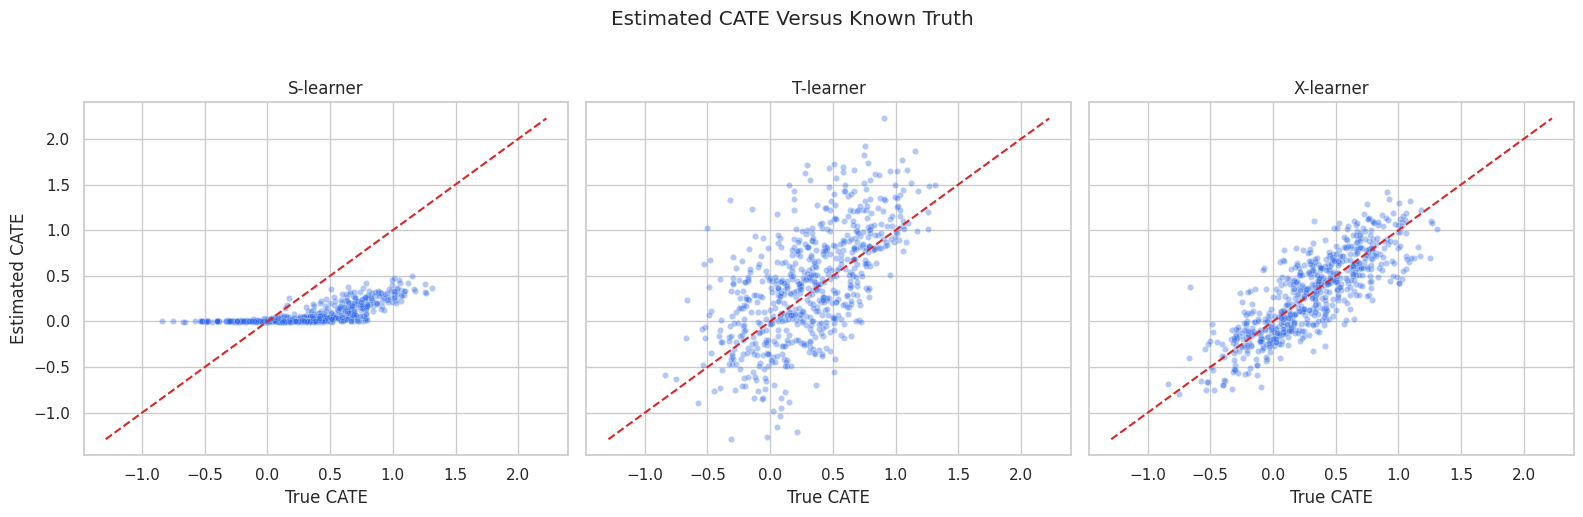

In [24]:
cate_plot_df = pd.concat(
    [
        pd.DataFrame({"true_cate": true_cate_test, "estimated_cate": s_cate_test, "learner": "S-learner"}),
        pd.DataFrame({"true_cate": true_cate_test, "estimated_cate": t_cate_test, "learner": "T-learner"}),
        pd.DataFrame({"true_cate": true_cate_test, "estimated_cate": x_cate_test, "learner": "X-learner"}),
    ],
    ignore_index=True,
)
limits = [
    min(cate_plot_df["true_cate"].min(), cate_plot_df["estimated_cate"].min()),
    max(cate_plot_df["true_cate"].max(), cate_plot_df["estimated_cate"].max()),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
for ax, (learner_name, learner_df) in zip(axes, cate_plot_df.groupby("learner")):
    sample_df = learner_df.sample(n=min(650, len(learner_df)), random_state=RANDOM_SEED)
    sns.scatterplot(data=sample_df, x="true_cate", y="estimated_cate", alpha=0.35, s=20, color="#2563eb", ax=ax)
    ax.plot(limits, limits, color="#dc2626", linestyle="--", linewidth=1.5)
    ax.set_title(learner_name)
    ax.set_xlabel("True CATE")
    ax.set_ylabel("Estimated CATE")

plt.suptitle("Estimated CATE Versus Known Truth", y=1.03)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "06_cate_recovery_scatter.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: each learner creates a different shape of CATE estimate. The best visual is not always the smoothest one; the goal is good recovery of true heterogeneity and useful ranking.

## Model-Agnostic CATE Sensitivity

EconML meta-learners do not all expose comparable feature importance objects. Instead, we can use a simple model-agnostic diagnostic: permute one feature at a time in the test set and measure how much the CATE predictions change.

This is not causal proof. It is a fitted-model sensitivity diagnostic.

In [25]:
def cate_permutation_sensitivity(estimator, X_reference, feature_names, rng_seed=RANDOM_SEED):
    local_rng = np.random.default_rng(rng_seed)
    base_effect = np.ravel(estimator.effect(X_reference))
    rows = []
    for feature in feature_names:
        X_perm = X_reference.copy()
        X_perm[feature] = local_rng.permutation(X_perm[feature].to_numpy())
        perm_effect = np.ravel(estimator.effect(X_perm))
        rows.append(
            {
                "feature": feature,
                "mean_abs_cate_change": np.mean(np.abs(base_effect - perm_effect)),
                "rmse_cate_change": np.sqrt(mean_squared_error(base_effect, perm_effect)),
            }
        )
    return pd.DataFrame(rows).sort_values("mean_abs_cate_change", ascending=False)

s_sensitivity = cate_permutation_sensitivity(s_learner, X_test, all_feature_cols).assign(learner="S-learner")
t_sensitivity = cate_permutation_sensitivity(t_learner, X_test, all_feature_cols).assign(learner="T-learner")
x_sensitivity = cate_permutation_sensitivity(x_learner, X_test, all_feature_cols).assign(learner="X-learner")

cate_sensitivity = pd.concat([s_sensitivity, t_sensitivity, x_sensitivity], ignore_index=True)
cate_sensitivity["true_cate_driver"] = cate_sensitivity["feature"].isin(true_driver_cols)
cate_sensitivity.to_csv(TABLE_DIR / "06_cate_permutation_sensitivity.csv", index=False)
display(cate_sensitivity.groupby("learner").head(8))

,feature,mean_abs_cate_change,rmse_cate_change,learner,true_cate_driver
0,prior_engagement,0.0581,0.1020,S-learner,True
1,baseline_need,0.0483,0.0946,S-learner,True
2,content_affinity,0.0385,0.0727,S-learner,True
3,friction_score,0.0155,0.0364,S-learner,True
4,account_tenure,0.0052,0.0118,S-learner,False
5,device_stability,0.0040,0.0125,S-learner,False
6,trust_score,0.0038,0.0085,S-learner,False
7,seasonality_index,0.0038,0.0089,S-learner,False
13,baseline_need,0.4552,0.5817,T-learner,True
14,content_affinity,0.4129,0.5586,T-learner,True


What this shows: permutation sensitivity tells us which features the fitted CATE functions rely on most. It is a useful way to compare learners when coefficients are not available.

## CATE Sensitivity Plot

The plot compares the top sensitivity features for each learner.

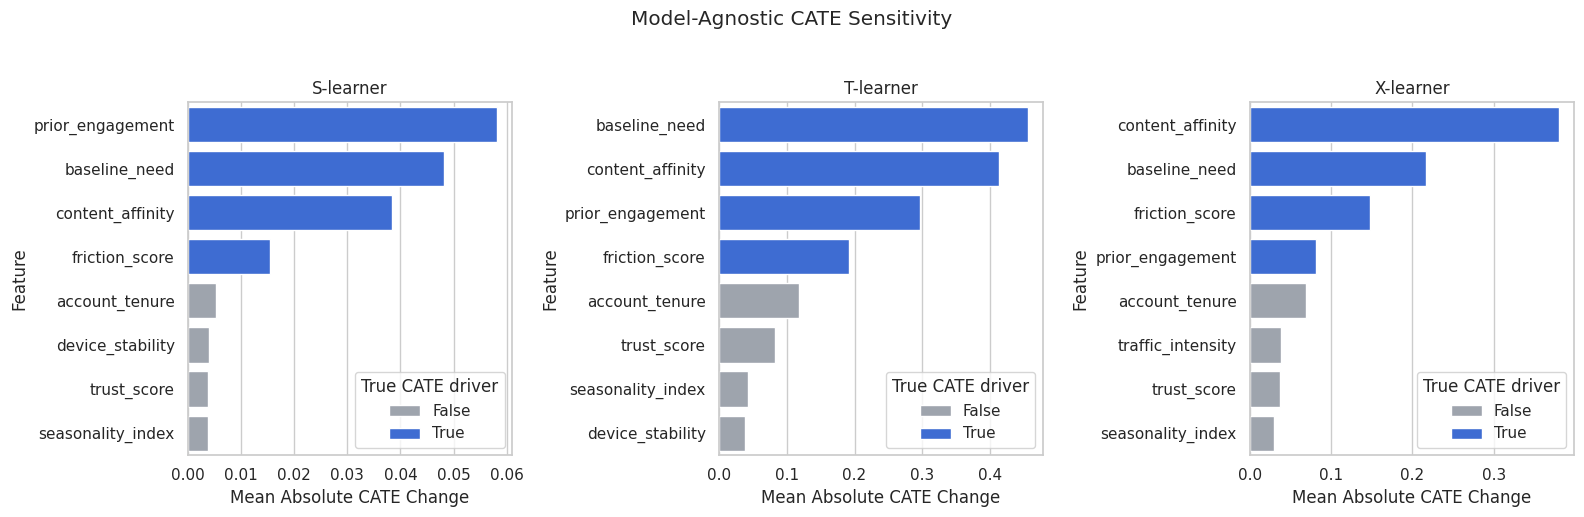

In [26]:
sensitivity_plot_df = (
    cate_sensitivity.sort_values(["learner", "mean_abs_cate_change"], ascending=[True, False])
    .groupby("learner", group_keys=False)
    .head(8)
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=False)
for ax, (learner_name, learner_df) in zip(axes, sensitivity_plot_df.groupby("learner")):
    sns.barplot(
        data=learner_df,
        x="mean_abs_cate_change",
        y="feature",
        hue="true_cate_driver",
        dodge=False,
        palette={True: "#2563eb", False: "#9ca3af"},
        ax=ax,
    )
    ax.set_title(learner_name)
    ax.set_xlabel("Mean Absolute CATE Change")
    ax.set_ylabel("Feature")
    ax.legend(title="True CATE driver")

plt.suptitle("Model-Agnostic CATE Sensitivity", y=1.03)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "06_cate_permutation_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: different meta-learners may rely on different features even when trained on the same data. That is a reason to compare methods rather than treating one learner as automatically correct.

## CATE Decile Calibration

CATE models are often used to rank units by expected benefit. The next table groups test rows by predicted CATE decile for each EconML learner.

In [27]:
test_results = test_df.assign(
    s_cate=s_cate_test,
    t_cate=t_cate_test,
    x_cate=x_cate_test,
    manual_s_cate=manual_s_cate_test,
    manual_t_cate=manual_t_cate_test,
    manual_x_cate=manual_x_cate_test,
)

calibration_frames = []
for learner_name, score_col in [("S-learner", "s_cate"), ("T-learner", "t_cate"), ("X-learner", "x_cate")]:
    temp = test_results.copy()
    temp["cate_decile"] = pd.qcut(temp[score_col], q=10, labels=False, duplicates="drop") + 1
    deciles = (
        temp.groupby("cate_decile", observed=True)
        .agg(
            rows=("outcome", "size"),
            estimated_cate=(score_col, "mean"),
            true_cate=("true_cate", "mean"),
            treatment_rate=("treatment", "mean"),
            propensity_mean=("propensity", "mean"),
        )
        .reset_index()
    )
    deciles["learner"] = learner_name
    calibration_frames.append(deciles)

cate_decile_calibration = pd.concat(calibration_frames, ignore_index=True)
cate_decile_calibration.to_csv(TABLE_DIR / "06_cate_decile_calibration.csv", index=False)
display(cate_decile_calibration)

,cate_decile,rows,estimated_cate,true_cate,treatment_rate,propensity_mean,learner
0,1,345,-0.0009,-0.0422,0.2174,0.1887,S-learner
1,2,103,0.0028,0.1704,0.2621,0.2777,S-learner
2,3,112,0.0095,0.1969,0.3214,0.3168,S-learner
3,4,112,0.0223,0.3141,0.3304,0.3465,S-learner
4,5,112,0.0434,0.3671,0.3036,0.3298,S-learner
5,6,112,0.0898,0.5228,0.3750,0.3734,S-learner
6,7,112,0.1798,0.6934,0.4464,0.4745,S-learner
7,8,112,0.3211,0.8941,0.6875,0.6831,S-learner
8,1,112,-0.6434,-0.0481,0.2232,0.2075,T-learner
9,2,112,-0.2616,0.0264,0.2411,0.2269,T-learner


What this shows: if a learner ranks well, higher predicted-effect deciles should have higher average true CATE. This check is central for treatment targeting.

## CATE Decile Calibration Plot

The plot compares estimated and true average CATE by predicted-effect decile.

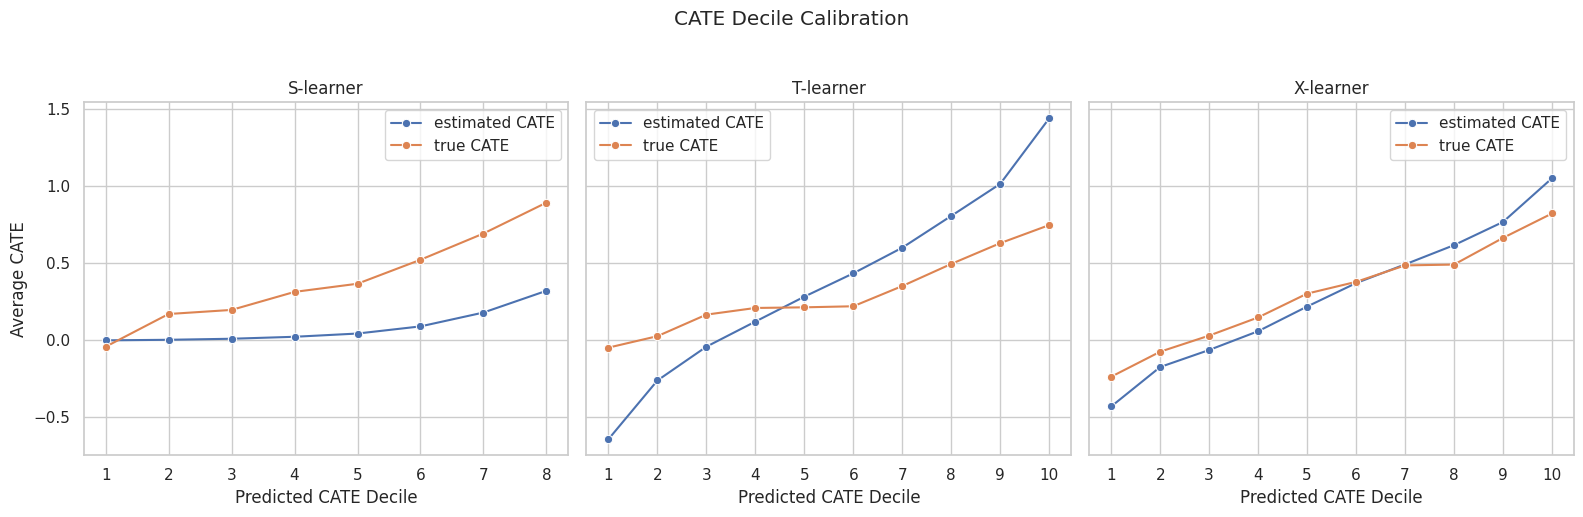

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, (learner_name, learner_df) in zip(axes, cate_decile_calibration.groupby("learner")):
    sns.lineplot(data=learner_df, x="cate_decile", y="estimated_cate", marker="o", label="estimated CATE", ax=ax)
    sns.lineplot(data=learner_df, x="cate_decile", y="true_cate", marker="o", label="true CATE", ax=ax)
    ax.set_title(learner_name)
    ax.set_xlabel("Predicted CATE Decile")
    ax.set_ylabel("Average CATE")
    ax.set_xticks(sorted(learner_df["cate_decile"].unique()))

plt.suptitle("CATE Decile Calibration", y=1.03)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "06_cate_decile_calibration.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: decile calibration turns CATE estimation into a ranking check. Even when point estimates are noisy, useful rankings can still support policy decisions.

## Segment-Level Recovery

Segment summaries make heterogeneous effects easier to communicate. Here we summarize by high-need segment and region risk.

In [29]:
segment_summary = (
    test_results.groupby(["high_need_segment", "region_risk"], observed=True)
    .agg(
        rows=("outcome", "size"),
        true_cate=("true_cate", "mean"),
        s_cate=("s_cate", "mean"),
        t_cate=("t_cate", "mean"),
        x_cate=("x_cate", "mean"),
        treatment_rate=("treatment", "mean"),
        propensity_mean=("propensity", "mean"),
    )
    .reset_index()
)
segment_summary["s_error"] = segment_summary["s_cate"] - segment_summary["true_cate"]
segment_summary["t_error"] = segment_summary["t_cate"] - segment_summary["true_cate"]
segment_summary["x_error"] = segment_summary["x_cate"] - segment_summary["true_cate"]

segment_summary.to_csv(TABLE_DIR / "06_segment_cate_recovery.csv", index=False)
display(segment_summary)

,high_need_segment,region_risk,rows,true_cate,s_cate,t_cate,x_cate,treatment_rate,propensity_mean,s_error,t_error,x_error
0,0,0,533,0.2734,0.0477,0.2739,0.2269,0.2064,0.2181,-0.2257,0.0005,-0.0465
1,0,1,265,0.0845,0.0393,0.2495,0.2023,0.2679,0.2591,-0.0452,0.1650,0.1178
2,1,0,231,0.5697,0.1240,0.6493,0.4630,0.5801,0.5764,-0.4457,0.0796,-0.1067
3,1,1,91,0.4173,0.1109,0.6468,0.4907,0.6923,0.6410,-0.3064,0.2295,0.0734


What this shows: segment-level results reveal whether a learner is accurate only on average or whether it captures broad subgroup differences.

## Segment Recovery Plot

This plot compares true and estimated segment-level effects for the three EconML meta-learners.

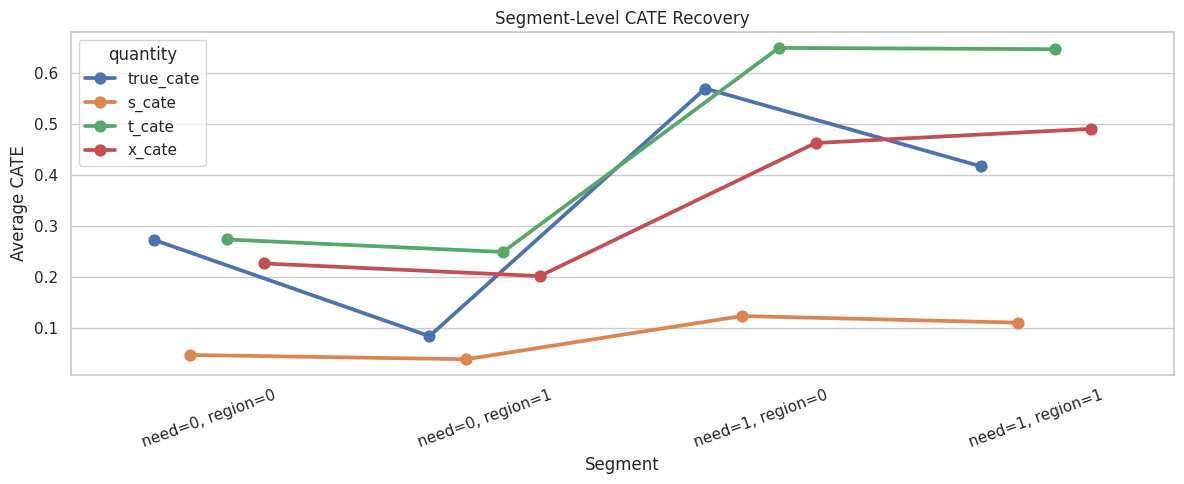

In [30]:
segment_plot_df = segment_summary.melt(
    id_vars=["high_need_segment", "region_risk", "rows"],
    value_vars=["true_cate", "s_cate", "t_cate", "x_cate"],
    var_name="quantity",
    value_name="average_cate",
)
segment_plot_df["segment"] = (
    "need=" + segment_plot_df["high_need_segment"].astype(str)
    + ", region=" + segment_plot_df["region_risk"].astype(str)
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.pointplot(
    data=segment_plot_df,
    x="segment",
    y="average_cate",
    hue="quantity",
    dodge=0.40,
    errorbar=None,
    ax=ax,
)
ax.set_title("Segment-Level CATE Recovery")
ax.set_xlabel("Segment")
ax.set_ylabel("Average CATE")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "06_segment_cate_recovery.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: segment summaries are often easier to explain than unit-level scatter plots. They also show whether treatment imbalance is hurting particular groups.

## Treatment Arm Support By Segment

Because meta-learners rely on outcome models by treatment arm, segment support matters. This table counts treated and control rows in each important segment.

In [31]:
segment_support = (
    train_df.groupby(["high_need_segment", "region_risk", "treatment"], observed=True)
    .agg(rows=("outcome", "size"), outcome_mean=("outcome", "mean"), true_cate_mean=("true_cate", "mean"))
    .reset_index()
    .pivot_table(
        index=["high_need_segment", "region_risk"],
        columns="treatment",
        values=["rows", "outcome_mean", "true_cate_mean"],
        aggfunc="first",
    )
)
segment_support.columns = [f"{metric}_treatment_{treatment}" for metric, treatment in segment_support.columns]
segment_support = segment_support.reset_index()
segment_support["treated_share"] = segment_support["rows_treatment_1"] / (
    segment_support["rows_treatment_0"] + segment_support["rows_treatment_1"]
)

segment_support.to_csv(TABLE_DIR / "06_segment_treatment_support.csv", index=False)
display(segment_support)

,high_need_segment,region_risk,outcome_mean_treatment_0,outcome_mean_treatment_1,rows_treatment_0,rows_treatment_1,true_cate_mean_treatment_0,true_cate_mean_treatment_1,treated_share
0,0,0,1.7940,2.4696,803,216,0.2071,0.3346,0.2120
1,0,1,2.0469,2.6665,346,117,0.0622,0.2156,0.2527
2,1,0,2.7563,3.6430,158,231,0.4842,0.5811,0.5938
3,1,1,2.6701,3.1785,70,139,0.3077,0.3412,0.6651


What this shows: segments with few treated rows are harder for treated-arm outcome models. This support view explains why T-learner estimates can be noisy in some regions.

## Targeting Comparison

A common use for CATE estimates is selecting the top fraction of units for treatment. The next cell compares random targeting, each EconML meta-learner, and an oracle benchmark.

In [32]:
targeting_fraction = 0.20
k = int(np.ceil(targeting_fraction * len(test_results)))
random_selected = test_results.sample(n=k, random_state=RANDOM_SEED).index
s_selected = test_results.sort_values("s_cate", ascending=False).head(k).index
t_selected = test_results.sort_values("t_cate", ascending=False).head(k).index
x_selected = test_results.sort_values("x_cate", ascending=False).head(k).index
oracle_selected = test_results.sort_values("true_cate", ascending=False).head(k).index

targeting_rows = []
for rule_name, selected_index in [
    ("random 20 percent", random_selected),
    ("top 20 percent by S-learner", s_selected),
    ("top 20 percent by T-learner", t_selected),
    ("top 20 percent by X-learner", x_selected),
    ("oracle top 20 percent by true CATE", oracle_selected),
]:
    selected = test_results.loc[selected_index]
    targeting_rows.append(
        {
            "targeting_rule": rule_name,
            "selected_rows": len(selected),
            "average_true_cate_in_selected_group": selected["true_cate"].mean(),
            "average_predicted_x_cate": selected["x_cate"].mean(),
            "share_high_need_segment": selected["high_need_segment"].mean(),
            "average_propensity": selected["propensity"].mean(),
        }
    )

targeting_summary = pd.DataFrame(targeting_rows)
targeting_summary["gain_vs_random_true_cate"] = (
    targeting_summary["average_true_cate_in_selected_group"]
    - targeting_summary.loc[targeting_summary["targeting_rule"].eq("random 20 percent"), "average_true_cate_in_selected_group"].iloc[0]
)

targeting_summary.to_csv(TABLE_DIR / "06_targeting_summary.csv", index=False)
display(targeting_summary)

,targeting_rule,selected_rows,average_true_cate_in_selected_group,average_predicted_x_cate,share_high_need_segment,average_propensity,gain_vs_random_true_cate
0,random 20 percent,224,0.3009,0.2865,0.3214,0.3395,0.0000
1,top 20 percent by S-learner,224,0.7937,0.7724,0.5312,0.5788,0.4928
2,top 20 percent by T-learner,224,0.6894,0.8004,0.4911,0.4950,0.3885
3,top 20 percent by X-learner,224,0.7443,0.9105,0.4018,0.4670,0.4433
4,oracle top 20 percent by true CATE,224,0.8482,0.7969,0.5804,0.5358,0.5472


What this shows: treatment targeting translates CATE ranking into an operational decision. The oracle benchmark is not achievable in real data, but it tells us how much room remains.

## Targeting Plot

This plot compares true average benefit among the selected rows under each rule.

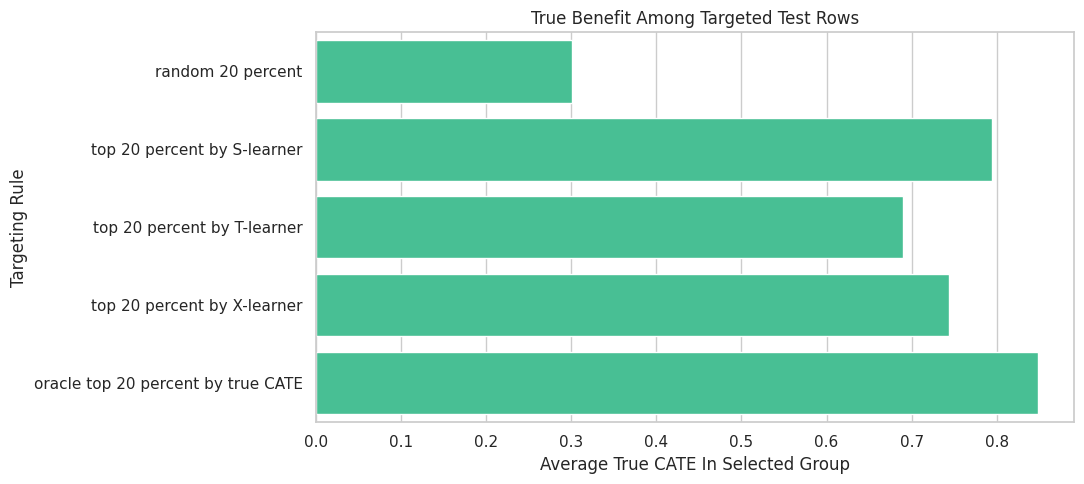

In [33]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=targeting_summary,
    x="average_true_cate_in_selected_group",
    y="targeting_rule",
    color="#34d399",
    ax=ax,
)
ax.set_title("True Benefit Among Targeted Test Rows")
ax.set_xlabel("Average True CATE In Selected Group")
ax.set_ylabel("Targeting Rule")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "06_targeting_summary.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: the best meta-learner depends on what the final use requires. For targeting, ranking quality often matters more than exact point-estimate calibration.

## Learner Selection Guidance

This table summarizes when each meta-learner is a reasonable first choice.

In [34]:
selection_guidance = pd.DataFrame(
    [
        {
            "situation": "You need a simple baseline quickly",
            "learner_to_try": "S-learner",
            "why": "One model is easy to fit and explain.",
            "watchout": "It may understate heterogeneity if treatment is not used strongly by the outcome model.",
        },
        {
            "situation": "Treatment and control groups are both large",
            "learner_to_try": "T-learner",
            "why": "Separate response surfaces can capture different outcome patterns by arm.",
            "watchout": "If one arm is small, that arm's model may be unstable.",
        },
        {
            "situation": "Treatment groups are imbalanced",
            "learner_to_try": "X-learner",
            "why": "Imputed-effect models can borrow strength from the larger arm.",
            "watchout": "It has more nuisance components and can be sensitive to propensity quality.",
        },
        {
            "situation": "The goal is robust causal adjustment with explicit nuisance modeling",
            "learner_to_try": "DRLearner or DML estimator",
            "why": "Meta-learners are outcome-model based and may not be enough for complex confounding.",
            "watchout": "Choose the estimator based on the design, not only prediction performance.",
        },
    ]
)

selection_guidance.to_csv(TABLE_DIR / "06_selection_guidance.csv", index=False)
display(selection_guidance)

,situation,learner_to_try,why,watchout
0,You need a simple baseline quickly,S-learner,One model is easy to fit and explain.,It may understate heterogeneity if treatment i...
1,Treatment and control groups are both large,T-learner,Separate response surfaces can capture differe...,"If one arm is small, that arm's model may be u..."
2,Treatment groups are imbalanced,X-learner,Imputed-effect models can borrow strength from...,It has more nuisance components and can be sen...
3,The goal is robust causal adjustment with expl...,DRLearner or DML estimator,Meta-learners are outcome-model based and may ...,"Choose the estimator based on the design, not ..."


What this shows: meta-learners are practical baselines and sometimes strong performers, but they are not automatically superior to DML or DR methods. The data shape and decision goal matter.

## Meta-Learner Checklist

Before presenting meta-learner CATE estimates, it is worth checking the items below.

In [35]:
meta_learner_checklist = pd.DataFrame(
    [
        {"check": "Treatment and outcome are clearly defined", "why_it_matters": "Meta-learners estimate a specific treatment contrast."},
        {"check": "All X features are pre-treatment", "why_it_matters": "Post-treatment features can contaminate potential outcome modeling."},
        {"check": "Important confounders are included in X", "why_it_matters": "The EconML meta-learner API has no separate W argument."},
        {"check": "Treatment-arm sample sizes are inspected", "why_it_matters": "T- and X-learners depend on arm-specific outcome models."},
        {"check": "Overlap is inspected", "why_it_matters": "Outcome models extrapolate when treated and control feature support differs."},
        {"check": "Outcome model quality is checked by arm", "why_it_matters": "Poor potential-outcome models produce poor CATE estimates."},
        {"check": "Multiple learners are compared", "why_it_matters": "Different meta-learners can tell different CATE stories."},
        {"check": "CATE rankings are evaluated", "why_it_matters": "Targeting depends on ranking, not only average effect."},
        {"check": "Segment summaries are reported", "why_it_matters": "Segments make unit-level estimates easier to audit and explain."},
    ]
)

meta_learner_checklist.to_csv(TABLE_DIR / "06_meta_learner_checklist.csv", index=False)
display(meta_learner_checklist)

,check,why_it_matters
0,Treatment and outcome are clearly defined,Meta-learners estimate a specific treatment co...
1,All X features are pre-treatment,Post-treatment features can contaminate potent...
2,Important confounders are included in X,The EconML meta-learner API has no separate W ...
3,Treatment-arm sample sizes are inspected,T- and X-learners depend on arm-specific outco...
4,Overlap is inspected,Outcome models extrapolate when treated and co...
5,Outcome model quality is checked by arm,Poor potential-outcome models produce poor CAT...
6,Multiple learners are compared,Different meta-learners can tell different CAT...
7,CATE rankings are evaluated,"Targeting depends on ranking, not only average..."
8,Segment summaries are reported,Segments make unit-level estimates easier to a...


What this shows: meta-learners are easy to fit, but credible use still requires causal design checks, outcome-model diagnostics, and support-aware reporting.

## Summary

This notebook compared S-, T-, and X-learners for heterogeneous treatment effects.

The main takeaways are:

- S-learners fit one outcome model and estimate effects by toggling treatment;
- T-learners fit separate outcome models for treated and untreated rows;
- X-learners impute treatment effects and can help when treatment arms are imbalanced;
- EconML meta-learners use one `X` matrix, so valid pre-treatment adjustment features must be included there;
- treatment imbalance makes arm-specific diagnostics important;
- CATE recovery should be evaluated through RMSE, correlation, decile calibration, segment summaries, and targeting performance;
- meta-learners are excellent baselines and teaching tools, but DML and DR learners may be better when adjustment structure is central.

The next tutorial can move from estimating CATE to using CATE estimates for policy learning and treatment targeting.